In [1]:
import numpy as np
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.titlesize": 14,
    }
)

folder_path = "../plotting_data/combined_spatial"

# List all .npy files
npy_files = [f for f in os.listdir(folder_path) if f.endswith(".npy")]

# Load all files into a dictionary
data = {}
file_names = []
for i in range(len(npy_files)):
    f = npy_files[i]
    file_path = os.path.join(folder_path, f)
    data[i] = np.load(file_path)
    file_names.append(f)

In [2]:
data_dir = "../plotting_data/rsds_spatial_raw/"

# Load Coordinates
lons = np.loadtxt(os.path.join(data_dir, "lons.txt"))
lats = np.loadtxt(os.path.join(data_dir, "lats.txt"))

# Load Model Names
with open(os.path.join(data_dir, "model_names_past.txt"), "r") as f:
    model_names_past = f.read().splitlines()

with open(os.path.join(data_dir, "model_names_future.txt"), "r") as f:
    model_names_future = f.read().splitlines()

/tmp/ipykernel_793654/2050915740.py:21: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(


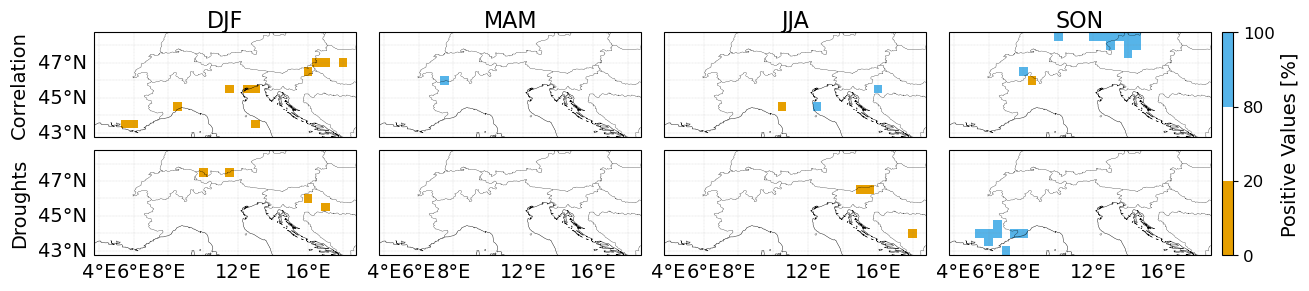

In [ ]:
colors = ["#E69F00", "white", "#56B4E9"]
cmap = ListedColormap(colors)
bounds = [0, 20, 80, 100]
norm = BoundaryNorm(bounds, ncolors=cmap.N)

seasons = ["DJF", "MAM", "JJA", "SON"]

selected_files = ["correlation.npy", "dunkelflauten.npy"]

fig, axes = plt.subplots(
    len(selected_files),
    len(seasons),
    figsize=(13, 2.8),
    subplot_kw={"projection": ccrs.PlateCarree()},
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
axes = axes.flatten()
plt.subplots_adjust(
    left=0.02, right=0.98, top=0.93, bottom=0.05, wspace=0.05, hspace=0.001
)

# --- Loop over files and seasons ---
for i, name in enumerate(selected_files):
    idx = [j for j, n in enumerate(file_names) if n == name]
    if not idx:
        continue
    score = idx[0]
    ds = np.asarray(data[score])

    # --- Compute % positive values ---
    positive_mask = ds > 0
    relative_var = np.mean(positive_mask, axis=0) * 100  # percent positive

    for j, season in enumerate(seasons):
        ax = axes[i * len(seasons) + j]
        if i == 0:
            ax.set_title(season, pad=2)
        ax.coastlines(linewidth=0.3)
        ax.add_feature(cfeature.BORDERS, linewidth=0.2)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)

        im = ax.pcolormesh(
            lons,
            lats,
            relative_var[j, :, :],
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            norm=norm,
            rasterized=True,
        )

        gl = ax.gridlines(
            draw_labels=True, linewidth=0.2, color="gray", alpha=0.5, linestyle="--"
        )
        gl.bottom_labels = i == len(selected_files) - 1
        gl.top_labels = False
        gl.left_labels = j == 0
        gl.right_labels = False

# --- Shared colorbar ---
cbar = fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.025, pad=0.01)
cbar.set_label("Positive Values [%]")
row_labels = ["Correlation", "Droughts"]
for i, label in enumerate(row_labels):
    ax_row = axes[i * len(seasons)]  # first column of each row
    ax_row.annotate(
        label,
        xy=(-0.25, 0.5),  # relative to axes
        xycoords="axes fraction",
        va="center",
        ha="right",
        fontsize=14,
        rotation="vertical",
    )


plt.savefig(
    "../plot/0064_location_wise_shift_combined.png", dpi=300, bbox_inches="tight"
)
plt.show()